Required imports for model.

In [2]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

Loading training dataset and splitting it into features 'X' (destination coordiantes, crime score, public safety score and crime severity) and target 'y' (safety scores).

In [2]:
# training_set = pd.read_csv("C:\\Users\\loisp\\Documents\\Year3\\Dissertation\\Proutect\\Proutect\\csv-json-files\\training_set.csv")

# X = training_set.drop('Safety Score', axis=1)
# y = training_set['Safety Score']
# print(X)
# print(y)

      Latitude  Longitude  Year  Crime Score  Crime Severity Score  \
0    52.295042  -1.570058  2021     0.017970              0.633333   
1    52.295042  -1.562762  2021     0.011809              0.663768   
2    52.295042  -1.555381  2021     0.010440              0.645902   
3    52.295042  -1.548171  2021     0.020195              0.519828   
4    52.295042  -1.540875  2021     0.083176              0.558974   
..         ...        ...   ...          ...                   ...   
226  52.268551  -1.526155  2023     0.010580              0.652542   
227  52.268551  -1.518688  2023     0.005643              0.715625   
228  52.268551  -1.511564  2023     0.000529              1.000000   
229  52.268551  -1.504140  2023     0.000000              0.000000   
230  52.268551  -1.497617  2023     0.000000              0.000000   

     Public Space Score  
0              0.000000  
1              0.000000  
2              0.003115  
3              0.006231  
4              0.015576  
.. 

Code to work out a particular lon/lat radius for some coordinates. 

In [47]:
def get_lat_lon_ranges(lat, lon, radius):
    # Earth's radius in meters
    EARTH_RADIUS = 6378137

    # Convert latitude and longitude from degrees to radians
    lat_rad = np.radians(lat)

    # Calculate deltas
    dLat = radius/EARTH_RADIUS
    dLon = radius/(EARTH_RADIUS * np.cos(lat_rad))

    # Convert deltas from radians to degrees
    dLat_deg = np.degrees(dLat)
    dLon_deg = np.degrees(dLon)

    # Define ranges
    lat_range = (lat - dLat_deg, lat + dLat_deg)
    lon_range = (lon - dLon_deg, lon + dLon_deg)

    return lat_range, lon_range

Defines crime datasets. 

In [71]:
crime_data_2021 = pd.read_csv('C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\crimes_in_range_2021.csv')
crime_data_2022 = pd.read_csv('C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\crimes_in_range_2022.csv')
crime_data_2023 = pd.read_csv('C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\crimes_in_range_2023.csv')

all_crime = pd.concat([crime_data_2021, crime_data_2022, crime_data_2023], ignore_index=True)

# Defining the crime severity score of each crime. 
crime_severity_scores = {
    "Drugs" : 2,
    "Shoplifting" : 2,
    "Burglary" : 5,
    "Theft from the person" : 8,
    "Possession of weapons" : 9,
    "Violence and sexual offences" : 10,
    "Criminal damage and arson" : 7,
    "Vehicle crime" : 4,
    "Bicycle theft " : 2,
    "Other theft" : 1,
    "Public order" : 1,
    "Robbery" : 5, 
    "Anti-social behaviour" : 5,
    "Other crime" : 1
}

# Function to get a spreadsheet of total crimes in a specified range.
def get_crimes_in_range(all_crime_data, long_min, long_max, lat_min, lat_max, crime_severity_scores):
    # Filter the data to only include crimes within the specified ranges
    crimes_in_range = all_crime_data[
        (all_crime_data['Longitude'] >= long_min) & 
        (all_crime_data['Longitude'] <= long_max) & 
        (all_crime_data['Latitude'] >= lat_min) & 
        (all_crime_data['Latitude'] <= lat_max)
    ]

    crimes_in_range = crimes_in_range.copy()
    
    # Add severity score for each crime
    crimes_in_range['Severity Score'] = crimes_in_range['Crime type'].map(crime_severity_scores)

    if not crimes_in_range.empty:
        avg_ss = crimes_in_range['Severity Score'].mean()
    else:
        avg_ss = 0

    return len(crimes_in_range), avg_ss

In [72]:
# Initialize dictionary to hold crime and safety score data
crime_dictionary = {}

# Iterate through the crimes
for index, row in all_crime.iterrows():
    # Convert to float once and use variables
    lat = float(row["Latitude"])
    lon = float(row["Longitude"])
    
    # Get coordinate ranges for 250m radius
    lat_range, lon_range = get_lat_lon_ranges(lat, lon, 250)
    
    # Define the coordinate pair
    coords = (lat, lon)
    
    # Initialize or update dictionary for the coords
    if coords not in crime_dictionary:
        crime_dictionary[coords] = [0, 0]  # Initialize if not present
    
    # Get number of crimes and average severity score in the range
    num_crimes, avg_ss = get_crimes_in_range(all_crime, lon_range[0], lat_range[0], lon_range[1], lat_range[1], crime_severity_scores)
    
    # Update dictionary values
    total_crimes = len(all_crime)

    crime_dictionary[coords][0] += (total_crimes - num_crimes) / total_crimes
    crime_dictionary[coords][1] += avg_ss

# Print the dictionary
print(crime_dictionary)

{(52.279611, -1.501874): [10.946635864857058, 70.24096385542168], (52.272738, -1.498624): [1.9978053710655501, 11.894736842105264], (52.276068, -1.499642): [4.982385215131389, 32.540983606557376], (52.294499, -1.530402): [5.951371643084032, 68.5706598334401], (52.293096, -1.530358): [22.52572913658679, 255.10338075969213], (52.294583, -1.529037): [19.291077100779674, 193.5788491446346], (52.292775, -1.530962): [20.315333525844622, 245.93477481782324], (52.292862, -1.534759): [10.678140340745014, 203.92410062677075], (52.292301, -1.529428): [9.15160265665608, 93.55905393190717], (52.291967, -1.535736): [46.56367311579565, 900.615489827322], (52.288299, -1.535877): [51.198151891423564, 647.898077368544], (52.293131, -1.536853): [34.319376263355515, 721.2973508294134], (52.29137, -1.532561): [5.977822697083455, 78.9602353197516], (52.289332, -1.537743): [4.50736355760901, 66.19938253162037], (52.292609, -1.536712): [71.7016459717007, 1497.0911197550229], (52.289063, -1.535854): [14.465492

Setting up data frame for classification analysis - setting the classification feature as a continous, average safety rating from users, while additionally adding the crime rate of each coordinate.  

In [76]:
from sklearn.preprocessing import StandardScaler

all_feedback = pd.read_csv('C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\joinedfeedback.csv')
ratings = all_feedback.loc[:, ['Latitude', 'Longitude', 'q1', 'q2', 'q3', 'q4']]
responses =  all_feedback.loc[:, ['Latitude', 'Longitude', 'responseList']]

# Initialize dictionary to hold crime and safety score data
crime_dictionary = {}

# Iterate through the crimes
for index, row in ratings.iterrows():
    # Convert to float once and use variables
    lat = float(row["Latitude"])
    lon = float(row["Longitude"])
    
    # Get coordinate ranges for 250m radius
    lat_range, lon_range = get_lat_lon_ranges(lat, lon, 250)
    
    # Define the coordinate pair
    coords = (lat, lon)
    
    # Initialize or update dictionary for the coords
    if coords not in crime_dictionary:
        crime_dictionary[coords] = [0, 0]  # Initialize if not present
    
    # Get number of crimes and average severity score in the range
    num_crimes, avg_ss = get_crimes_in_range(all_crime, lon_range[0], lat_range[0], lon_range[1], lat_range[1], crime_severity_scores)
    
    # Update dictionary values
    total_crimes = len(all_crime)

    crime_dictionary[coords][0] += (total_crimes - num_crimes) / total_crimes
    crime_dictionary[coords][1] += avg_ss

# Appending the average "safety score" that is given by the users 
classification_list = []
crime_num_list = []
crime_sev_list = []

for index, row in ratings.iterrows():
    classification_list.append(row['q1'])

    coords = (row["Latitude"], row["Longitude"])

    crime_num_list.append(crime_dictionary[coords][0])
    crime_sev_list.append(crime_dictionary[coords][1])


ratings["Classification"] = classification_list
ratings["Crime Score"] = crime_num_list
ratings["Severity Score"] = crime_sev_list

scaler = StandardScaler()
ratings[['Crime Score', 'Severity Score']] = scaler.fit_transform(ratings[['Crime Score', 'Severity Score']])

# ratings
# ratings["Classification"].value_counts()

X_2 = ratings.drop(['Classification', 'q1'], axis=1)

y_2 = ratings['Classification']

print(X_2)
print(y_2)

      Latitude  Longitude    q2    q3    q4  Crime Score  Severity Score
0    52.285500  -1.558030  4.00  4.00  1.00     0.431591        5.993190
1    52.286880  -1.533620  3.00  2.00  1.00     0.553682        6.255490
2    52.279250  -1.544650  3.00  2.00  1.00     0.738724        6.188996
3    52.290777  -1.533494  3.75  4.00  1.75     0.414727        6.015222
4    52.275950  -1.516430  3.00  3.00  1.00     0.958071        6.337969
..         ...        ...   ...   ...   ...          ...             ...
779  52.292370  -1.548190  2.75  3.25  2.00     0.149177        5.802701
780  52.285970  -1.536280  2.00  1.50  1.00     0.573029        6.306509
781  52.282960  -1.545510  2.00  1.50  1.00     0.558995        5.955777
782  52.288400  -1.538270  2.00  1.00  1.00     0.466070        6.207774
783  52.289680  -1.542560  2.00  3.00  2.00     0.332833        5.933322

[784 rows x 7 columns]
0      3.0
1      3.0
2      3.0
3      3.5
4      3.0
      ... 
779    3.0
780    2.5
781    2.5
7

In [44]:
crime_data_2021 = pd.read_csv('C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\crimes_in_range_2021.csv')
crime_data_2022 = pd.read_csv('C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\crimes_in_range_2022.csv')
crime_data_2023 = pd.read_csv('C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\crimes_in_range_2023.csv')

all_crime = pd.concat([crime_data_2021, crime_data_2022, crime_data_2023], ignore_index=True)

# Defining the crime severity score of each crime. 
crime_severity_scores = {
    "Drugs" : 2,
    "Shoplifting" : 2,
    "Burglary" : 5,
    "Theft from the person" : 8,
    "Possession of weapons" : 9,
    "Violence and sexual offences" : 10,
    "Criminal damage and arson" : 7,
    "Vehicle crime" : 4,
    "Bicycle theft " : 2,
    "Other theft" : 1,
    "Public order" : 1,
    "Robbery" : 5, 
    "Anti-social behaviour" : 5,
    "Other crime" : 1
}


# Function to get a spreadsheet of total crimes in a specified range.
def get_crimes_in_range(all_crime_data, long_min, long_max, lat_min, lat_max, crime_severity_scores):
    # Filter the data to only include crimes within the specified ranges
    crimes_in_range = all_crime_data[
        (all_crime_data['Longitude'] >= long_min) & 
        (all_crime_data['Longitude'] <= long_max) & 
        (all_crime_data['Latitude'] >= lat_min) & 
        (all_crime_data['Latitude'] <= lat_max)
    ]

    crimes_in_range = crimes_in_range.copy()
    
    # Add severity score for each crime
    crimes_in_range['Severity Score'] = crimes_in_range['Crime type'].map(crime_severity_scores)
    # print(crimes_in_range)
    # Calculate average severity score for the crimes in the range
    
    if not crimes_in_range.empty:
        average_severity_score = crimes_in_range['Severity Score'].mean()
    else:
        average_severity_score = 0

    return len(crimes_in_range), average_severity_score


                                                Crime ID    Month  \
0      0e3bfa524bbc64185a577632590edbe2ec9a07c37709c0...  2021-01   
1      ea68e4642d29d6fdc6c68f131a477f03885dd0c1ef0c70...  2021-01   
2      c9fefc0a75eaed1e4fb17d5ee05b1625ca0695168afffc...  2021-01   
3      16ffdb5b431d09fec9985e49841a250d2a8c14d1b995eb...  2021-01   
4                                                    NaN  2021-01   
...                                                  ...      ...   
17310  efcfe07879b843bcd9222baf265728f6eb3d975c92a1a3...  2023-12   
17311                                                NaN  2023-12   
17312  6b3f47c32aff9a0831c4b1afe18c75556eb77cdda0fb84...  2023-12   
17313  2ab834f2e8db1830a82f07f624611851a9cc02c49f476f...  2023-12   
17314  dd1538972b2aff84d294556824460d57558a7d8a39230f...  2023-12   

               Reported by         Falls within  Longitude   Latitude  \
0      Warwickshire Police  Warwickshire Police  -1.501874  52.279611   
1      Warwickshire Polic

Split data into training/test set.

In [77]:
# 80% : 20% split
X_train, X_test, y_train, y_test = train_test_split(X_2, y_2, test_size=0.2, random_state=42)

In [78]:
regressor = RandomForestRegressor(n_estimators=100, random_state=42, oob_score = True)
regressor.fit(X_train, y_train)

RandomForestRegressor(oob_score=True, random_state=42)

In [79]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

# Predicting on the test set
y_pred = regressor.predict(X_test)

# Calculating the Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse}")

mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae}")

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse}")

RMSE: 0.12316374978509234
Mean Absolute Error (MAE): 0.03664611768274191
Mean Squared Error (MSE): 0.015169309261124834


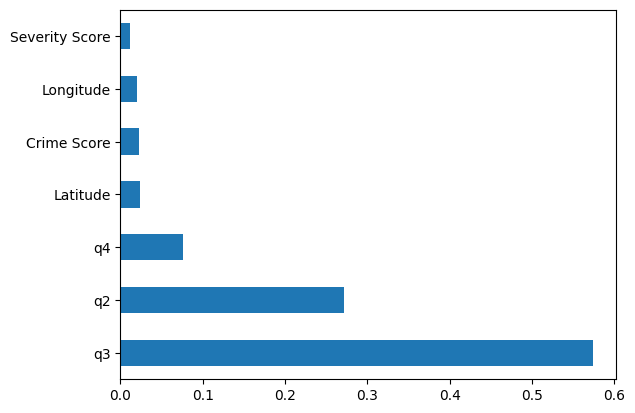

In [80]:
feature_importances = pd.Series(regressor.feature_importances_, index=X_2.columns)
feature_importances.nlargest(10).plot(kind='barh')  # Top 10 features
plt.show()

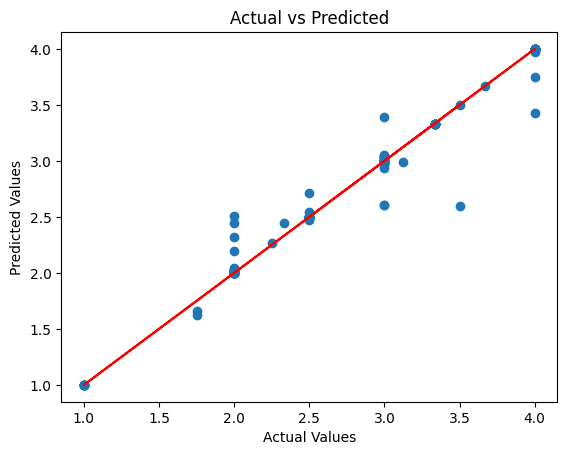

In [81]:
import matplotlib.pyplot as plt

# Scatter plot for actual vs predicted values
plt.scatter(x=y_test, y=y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.plot(y_test, y_test, color='red')  # Line for perfect predictions
plt.show()